# 🔧 Notebook 02 – Feature Engineering

**Objective:** Transform raw OHLCV data into a rich feature matrix suitable for ML models.

---
### Table of Contents
1. Load Cleaned Data
2. Lag Features
3. Moving Averages & EMA
4. RSI
5. MACD
6. Bollinger Bands
7. Volume & Volatility Features
8. Time Features
9. Target Variable
10. Feature Correlation & Selection Preview
11. Save Feature Dataset


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

from feature_engineering import (
    add_lag_features, add_moving_averages, add_ema,
    add_rsi, add_macd, add_bollinger_bands,
    add_volume_features, add_volatility, add_time_features,
    add_target, build_features, get_feature_columns
)
from utils import ensure_sample_data, set_plot_style
from data_preprocessing import preprocess

set_plot_style()
print('✅ Setup complete.')


✅ Setup complete.


In [2]:
# ── 1. Load Cleaned Data ─────────────────────────────────────────────────────
CLEAN_PATH = '../data/processed/stock_data_clean.csv'
RAW_PATH   = '../data/raw/stock_data.csv'

ensure_sample_data(RAW_PATH)

if os.path.exists(CLEAN_PATH):
    df = pd.read_csv(CLEAN_PATH, parse_dates=['Date'])
else:
    df = preprocess(RAW_PATH, save_path=CLEAN_PATH)

print(f'Loaded {len(df)} rows | Columns: {df.columns.tolist()}')
display(df[['Date','Open','High','Low','Close','Volume']].tail(3))


Loaded 1000 rows | Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker', 'Daily_Return', 'HL_Spread', 'OC_Spread', 'Log_Return']


,Date,Open,High,Low,Close,Volume
997,2022-10-27,160.30,162.60,160.88,161.88,6121632
998,2022-10-28,161.88,160.68,160.28,160.55,6896721
999,2022-10-31,160.55,162.58,161.85,161.97,1551238


2026-05-01 20:43:11 | INFO     | feature_engineering | Added 10 lag features for 'Close'.



📌 Lag Features (last 5 rows):


,Date,Close,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,Close_lag_5,Close_lag_6,Close_lag_7,Close_lag_8,Close_lag_9,Close_lag_10
995,2022-10-25,156.04,156.65,159.00,160.59,161.14,166.18,165.61,165.49,166.00,163.79,160.13
996,2022-10-26,160.30,156.04,156.65,159.00,160.59,161.14,166.18,165.61,165.49,166.00,163.79
997,2022-10-27,161.88,160.30,156.04,156.65,159.00,160.59,161.14,166.18,165.61,165.49,166.00
998,2022-10-28,160.55,161.88,160.30,156.04,156.65,159.00,160.59,161.14,166.18,165.61,165.49
999,2022-10-31,161.97,160.55,161.88,160.30,156.04,156.65,159.00,160.59,161.14,166.18,165.61


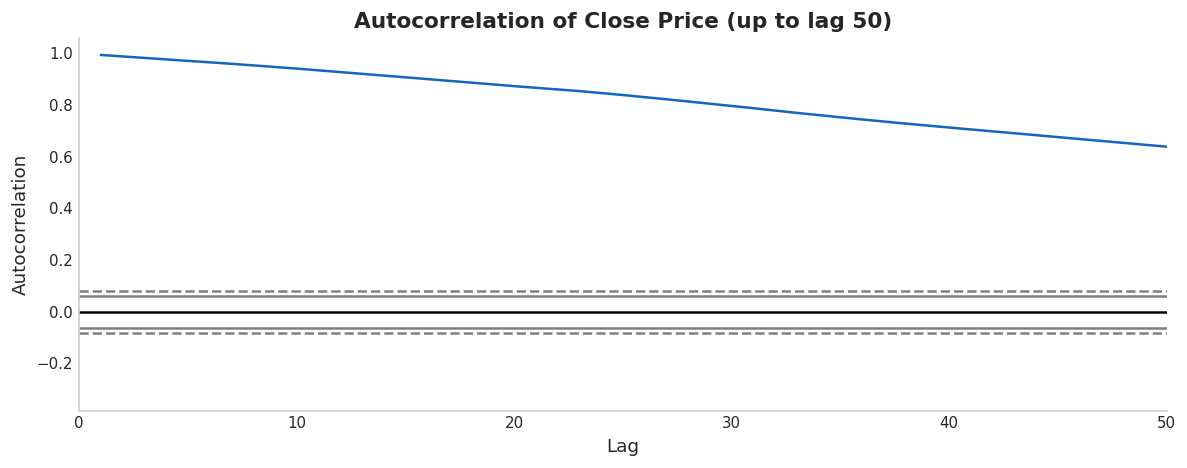


💡 High autocorrelation → lag features will be strong predictors.


In [3]:
# ── 2. Lag Features ──────────────────────────────────────────────────────────
df_feat = df.copy()
df_feat = add_lag_features(df_feat, col='Close', lags=10)

lag_cols = [f'Close_lag_{i}' for i in range(1, 11)]
print('\n📌 Lag Features (last 5 rows):')
display(df_feat[['Date','Close'] + lag_cols].tail())

# Visualise autocorrelation
fig, ax = plt.subplots(figsize=(10, 4))
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df_feat['Close'].dropna(), ax=ax, color='#1565C0')
ax.set_xlim(0, 50)
ax.set_title('Autocorrelation of Close Price (up to lag 50)', fontweight='bold')
plt.tight_layout(); plt.show()
print('\n💡 High autocorrelation → lag features will be strong predictors.')


2026-05-01 20:43:18 | INFO     | feature_engineering | Added SMA for windows [7, 14, 30].
2026-05-01 20:43:18 | INFO     | feature_engineering | Added EMA for spans [12, 26].


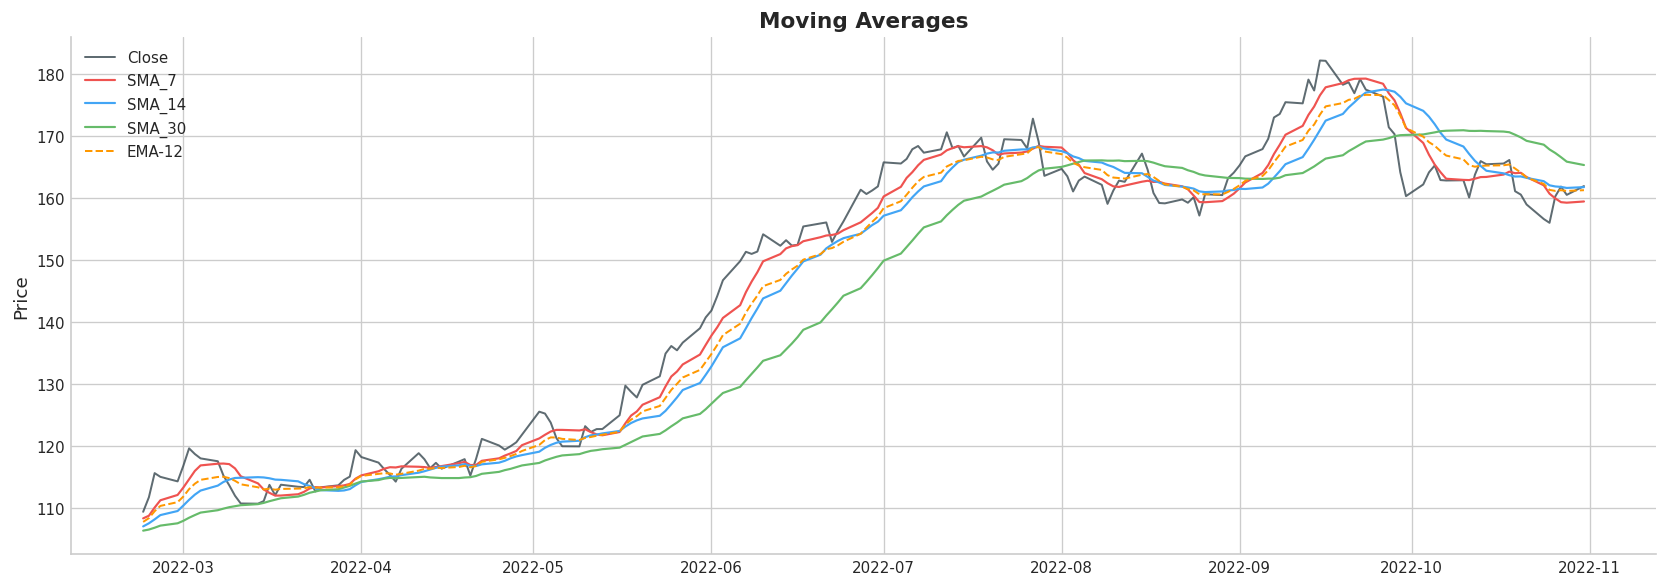

In [4]:
# ── 3. Moving Averages & EMA ─────────────────────────────────────────────────
df_feat = add_moving_averages(df_feat, windows=[7, 14, 30])
df_feat = add_ema(df_feat, spans=[12, 26])

tail = df_feat.tail(180)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tail['Date'], tail['Close'],  label='Close',    color='#37474F', linewidth=1.2, alpha=0.8)
for col, color in zip(['SMA_7','SMA_14','SMA_30'], ['#EF5350','#42A5F5','#66BB6A']):
    ax.plot(tail['Date'], tail[col], label=col, color=color, linewidth=1.3)
ax.plot(tail['Date'], tail['EMA_12'], label='EMA-12', color='#FF9800', linestyle='--', linewidth=1.2)
ax.set_title('Moving Averages', fontweight='bold')
ax.legend(); ax.set_ylabel('Price')
plt.tight_layout(); plt.show()


2026-05-01 20:43:24 | INFO     | feature_engineering | Added RSI(14).


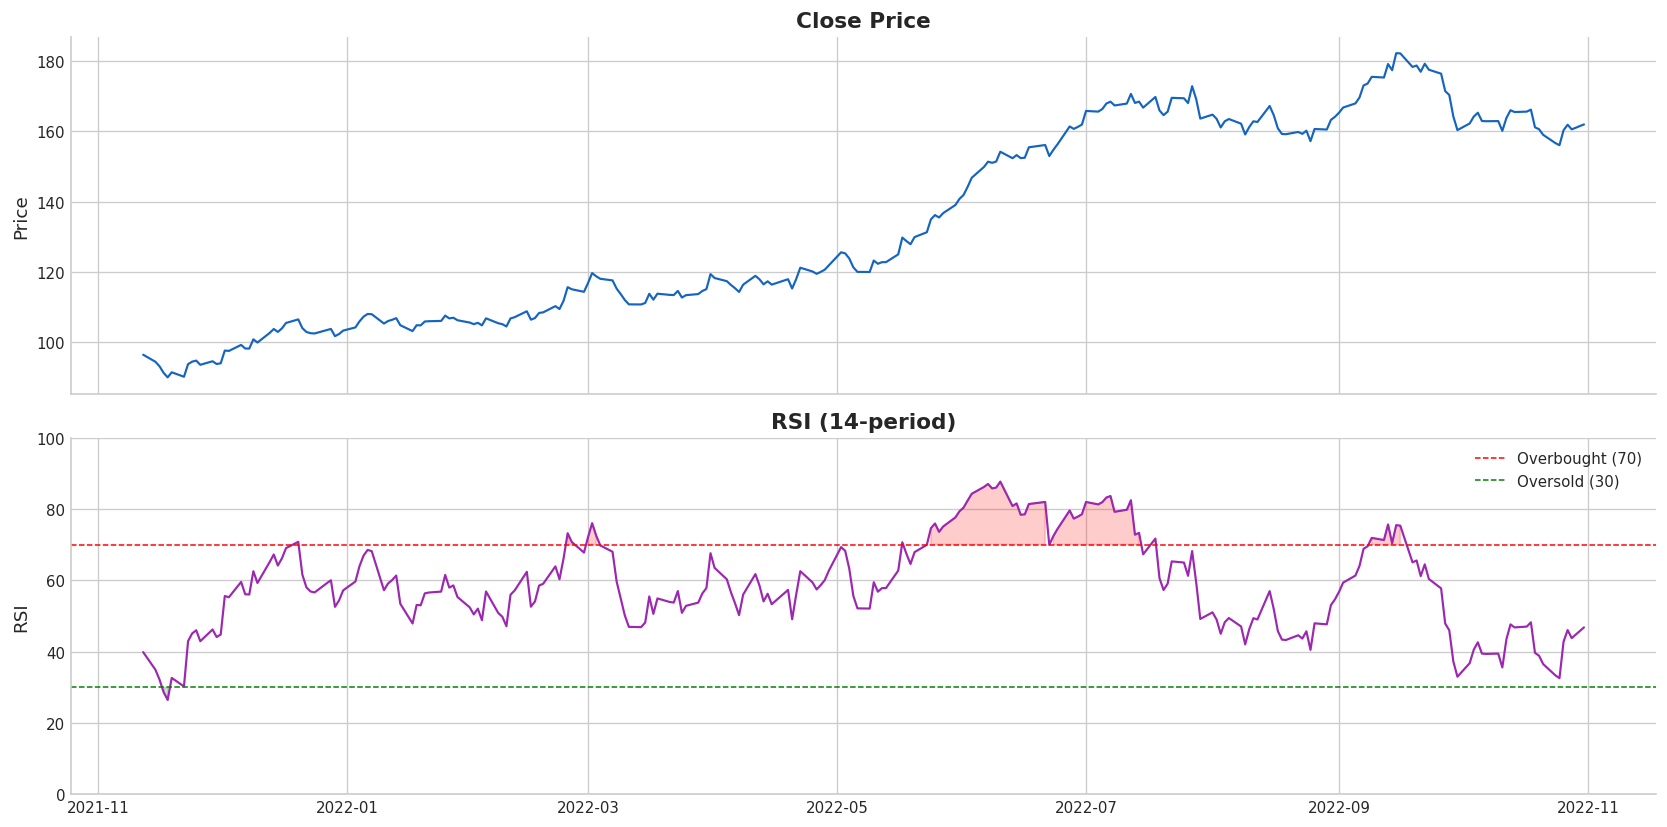


💡 Last year: 51 overbought days, 2 oversold days.


In [5]:
# ── 4. RSI ────────────────────────────────────────────────────────────────────
df_feat = add_rsi(df_feat)
tail    = df_feat.tail(252)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(tail['Date'], tail['Close'], color='#1565C0', linewidth=1.3)
ax1.set_title('Close Price', fontweight='bold'); ax1.set_ylabel('Price')

ax2.plot(tail['Date'], tail['RSI'], color='#9C27B0', linewidth=1.3)
ax2.axhline(70, color='red',   linestyle='--', linewidth=0.9, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', linewidth=0.9, label='Oversold (30)')
ax2.fill_between(tail['Date'], tail['RSI'], 70, where=(tail['RSI']>=70), alpha=0.2, color='red')
ax2.fill_between(tail['Date'], tail['RSI'], 30, where=(tail['RSI']<=30), alpha=0.2, color='green')
ax2.set_title('RSI (14-period)', fontweight='bold'); ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

overbought = (tail['RSI'] > 70).sum()
oversold   = (tail['RSI'] < 30).sum()
print(f'\n💡 Last year: {overbought} overbought days, {oversold} oversold days.')


2026-05-01 20:43:31 | INFO     | feature_engineering | Added MACD(12,26,9).


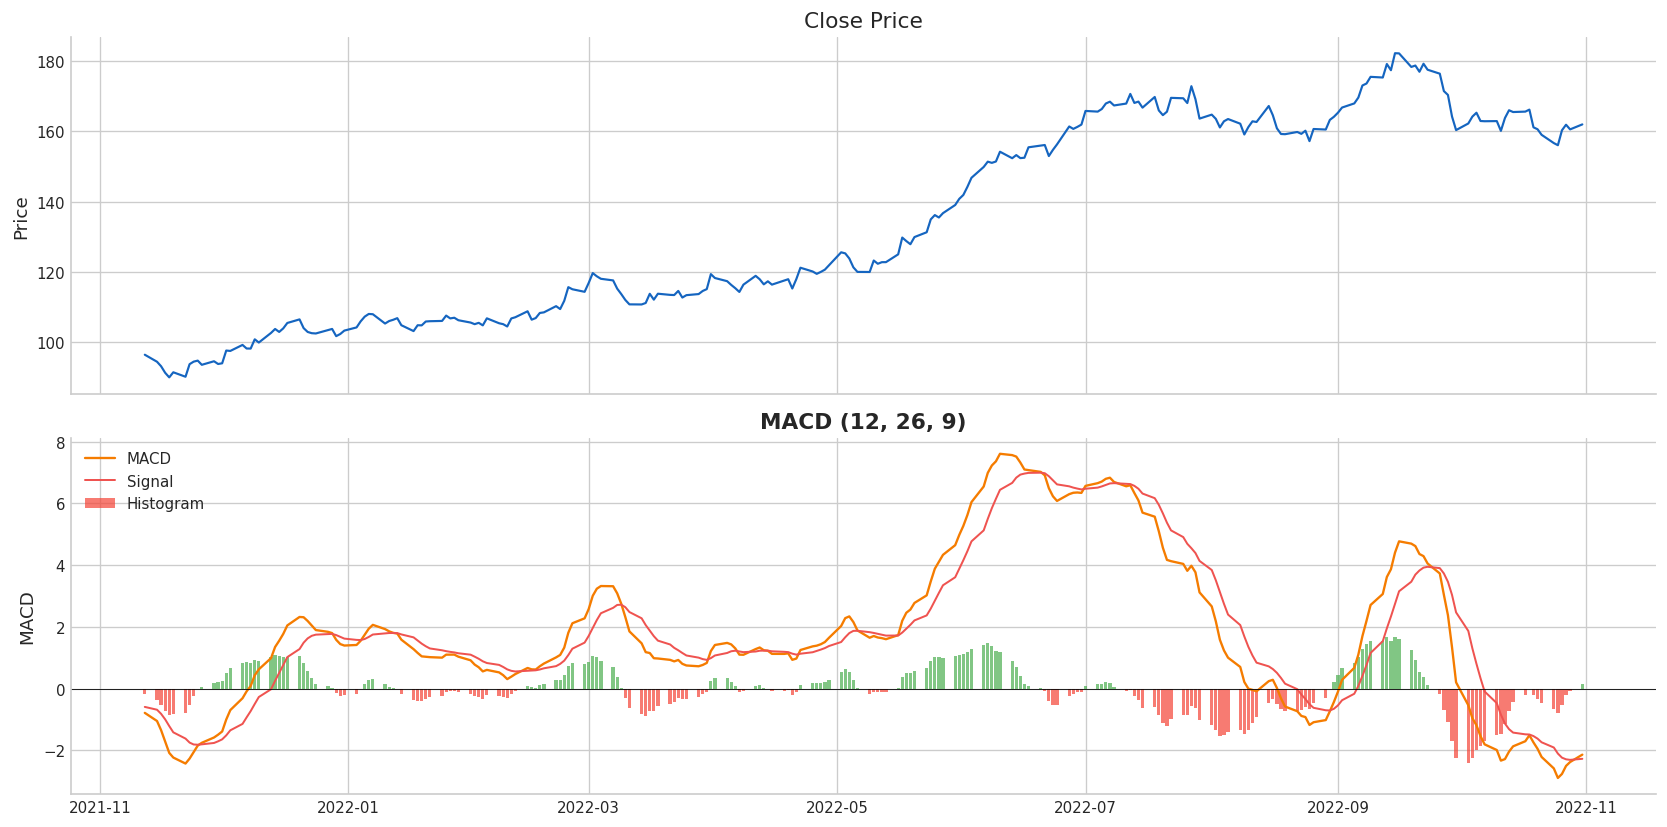

In [6]:
# ── 5. MACD ───────────────────────────────────────────────────────────────────
df_feat = add_macd(df_feat)
tail    = df_feat.tail(252)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(tail['Date'], tail['Close'], color='#1565C0', linewidth=1.3)
ax1.set_title('Close Price'); ax1.set_ylabel('Price')

ax2.plot(tail['Date'], tail['MACD'],        label='MACD',   color='#F57C00', linewidth=1.4)
ax2.plot(tail['Date'], tail['MACD_Signal'], label='Signal', color='#EF5350', linewidth=1.2)
colors = ['#4CAF50' if v >= 0 else '#F44336' for v in tail['MACD_Hist']]
ax2.bar(tail['Date'], tail['MACD_Hist'], color=colors, alpha=0.7, width=0.8, label='Histogram')
ax2.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax2.set_title('MACD (12, 26, 9)', fontweight='bold'); ax2.set_ylabel('MACD')
ax2.legend(loc='upper left')
plt.tight_layout(); plt.show()


2026-05-01 20:43:42 | INFO     | feature_engineering | Added Bollinger Bands(20, 2σ).


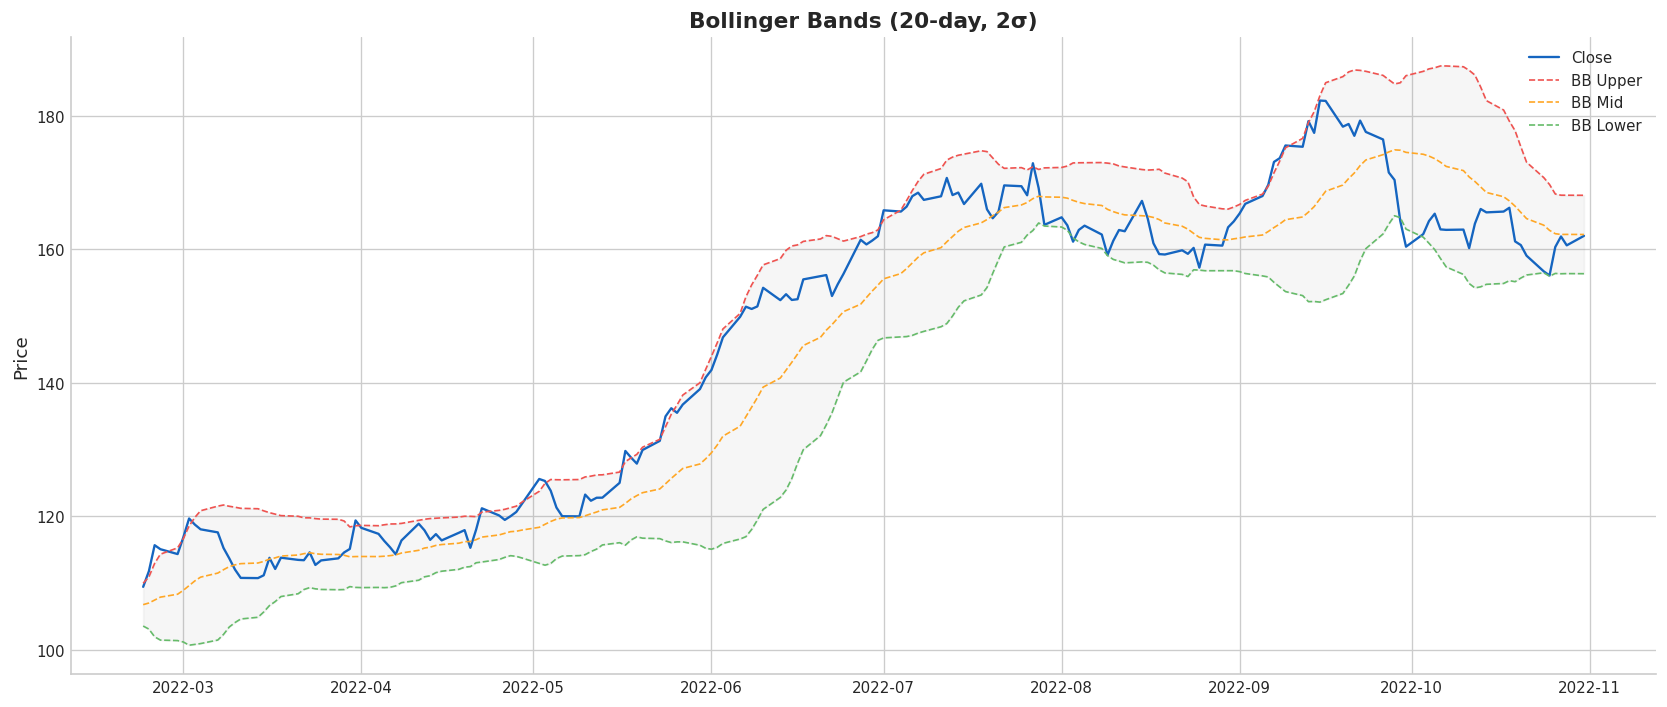


💡 Price touches upper band → potential mean-reversion sell signal.


In [7]:
# ── 6. Bollinger Bands ────────────────────────────────────────────────────────
df_feat = add_bollinger_bands(df_feat)
tail    = df_feat.tail(180)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(tail['Date'], tail['Close'],    label='Close',    color='#1565C0', linewidth=1.4)
ax.plot(tail['Date'], tail['BB_Upper'], label='BB Upper', color='#EF5350', linestyle='--', linewidth=1)
ax.plot(tail['Date'], tail['BB_Mid'],   label='BB Mid',   color='#FFA726', linestyle='--', linewidth=1)
ax.plot(tail['Date'], tail['BB_Lower'], label='BB Lower', color='#66BB6A', linestyle='--', linewidth=1)
ax.fill_between(tail['Date'], tail['BB_Upper'], tail['BB_Lower'], alpha=0.07, color='grey')
ax.set_title('Bollinger Bands (20-day, 2σ)', fontweight='bold')
ax.set_ylabel('Price'); ax.legend()
plt.tight_layout(); plt.show()
print('\n💡 Price touches upper band → potential mean-reversion sell signal.')


In [8]:
# ── 7. Volume & Volatility Features ──────────────────────────────────────────
df_feat = add_volume_features(df_feat)
df_feat = add_volatility(df_feat)
print('Volume and volatility features added.')
display(df_feat[['Date','Volume','Volume_MA7','Volume_Ratio','Volatility_7','Volatility_30']].tail())


2026-05-01 20:43:47 | INFO     | feature_engineering | Added volume features.
2026-05-01 20:43:47 | INFO     | feature_engineering | Added rolling volatility for windows [7, 14, 30].


Volume and volatility features added.


,Date,Volume,Volume_MA7,Volume_Ratio,Volatility_7,Volatility_30
995,2022-10-25,9227489,3.895672e+06,2.368651,0.011492,0.015061
996,2022-10-26,6147501,4.491728e+06,1.368627,0.017691,0.016097
997,2022-10-27,6121632,4.647229e+06,1.317265,0.018326,0.015249
998,2022-10-28,6896721,4.716157e+06,1.462360,0.014445,0.015254
999,2022-10-31,1551238,4.715499e+06,0.328966,0.014763,0.015078


2026-05-01 20:43:50 | INFO     | feature_engineering | Added time features.


Day-of-week return distribution:


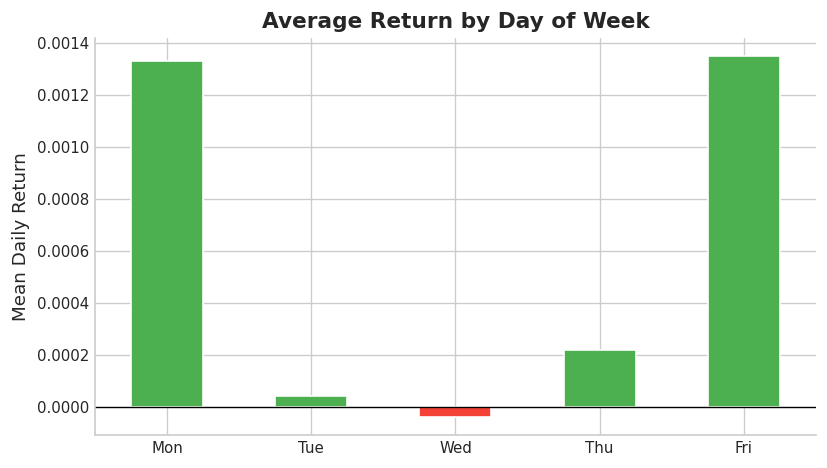

In [9]:
# ── 8. Time Features ─────────────────────────────────────────────────────────
df_feat = add_time_features(df_feat)

print('Day-of-week return distribution:')
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri'}
df_feat['DayName'] = df_feat['DayOfWeek'].map(day_map)
day_ret = df_feat.groupby('DayName')['Daily_Return'].mean().reindex(['Mon','Tue','Wed','Thu','Fri'])

fig, ax = plt.subplots(figsize=(7, 4))
colors  = ['#4CAF50' if v > 0 else '#F44336' for v in day_ret]
day_ret.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Return by Day of Week', fontweight='bold')
ax.set_ylabel('Mean Daily Return'); ax.set_xlabel('')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


In [10]:
# ── 9. Target Variable ────────────────────────────────────────────────────────
df_feat = add_target(df_feat)

# Drop warmup NaN rows
df_feat = df_feat.dropna().reset_index(drop=True)

print(f'Final feature dataset: {df_feat.shape}')
print(f'\nTarget distribution (classification):')
counts = df_feat['Target_Dir'].value_counts()
print(f'  UP   (1): {counts.get(1,0)} ({counts.get(1,0)/len(df_feat)*100:.1f}%)')
print(f'  DOWN (0): {counts.get(0,0)} ({counts.get(0,0)/len(df_feat)*100:.1f}%)')


Final feature dataset: (989, 49)

Target distribution (classification):
  UP   (1): 509 (51.5%)
  DOWN (0): 480 (48.5%)


Encoding non-numeric columns: ['DayName']


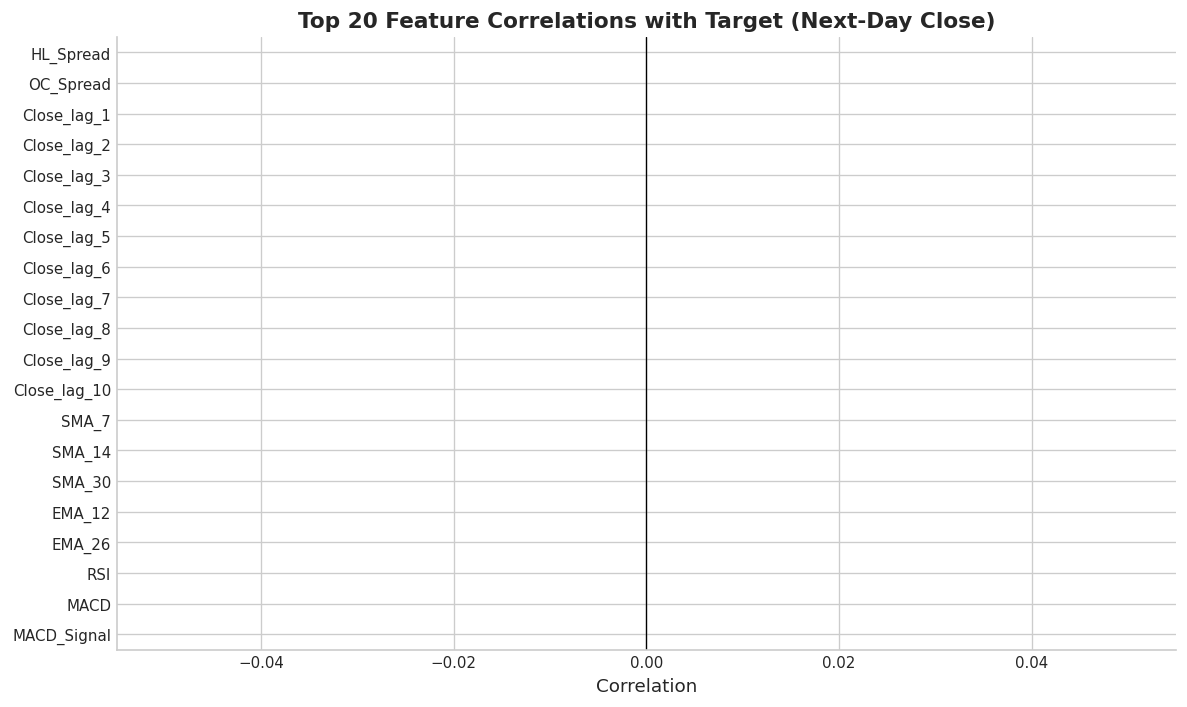


Total features: 38
Top 5 predictors: ['HL_Spread', 'OC_Spread', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3']


In [12]:
# # ── 10. Feature Correlation with Target ───────────────────────────────────────
# feature_cols = get_feature_columns(df_feat)
# corr_target  = df_feat[feature_cols + ['Target_Close']].corr()['Target_Close'].drop('Target_Close')
# top20        = corr_target.abs().nlargest(20)

# fig, ax = plt.subplots(figsize=(10, 6))
# colors  = ['#4CAF50' if v > 0 else '#F44336' for v in corr_target[top20.index]]
# corr_target[top20.index][::-1].plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='none')
# ax.set_title('Top 20 Feature Correlations with Target (Next-Day Close)', fontweight='bold')
# ax.set_xlabel('Correlation')
# ax.axvline(0, color='black', linewidth=0.8)
# plt.tight_layout(); plt.show()

# print(f'\nTotal features: {len(feature_cols)}')
# print('Top 5 predictors:', top20.index[:5].tolist())

# ── 10. Feature Correlation with Target ───────────────────────────────────────

# Get feature columns
feature_cols = get_feature_columns(df_feat)

# Ensure Target exists
if 'Target_Close' not in df_feat.columns:
    raise ValueError("Target_Close column not found in dataframe")

# Subset dataframe
subset = df_feat[feature_cols + ['Target_Close']].copy()

# ── Handle non-numeric columns safely ─────────────────────────────────────────

# Option 1: Convert common categorical time features if present
if 'DayOfWeek' in subset.columns:
    subset['DayOfWeek'] = subset['DayOfWeek'].map({
        'Mon':1, 'Tue':2, 'Wed':3, 'Thu':4, 'Fri':5, 'Sat':6, 'Sun':7
    })

# Convert any remaining object/category columns using one-hot encoding
non_numeric_cols = subset.select_dtypes(exclude=['number']).columns.tolist()

if non_numeric_cols:
    print("Encoding non-numeric columns:", non_numeric_cols)
    subset = pd.get_dummies(subset, columns=non_numeric_cols, drop_first=True)

# Final numeric safety check
subset = subset.select_dtypes(include=['number'])

# Drop rows with NaNs (important for correlation)
subset = subset.dropna()

# ── Correlation computation ───────────────────────────────────────────────────

corr_matrix = subset.corr()

if 'Target_Close' not in corr_matrix.columns:
    raise ValueError("Target_Close missing after preprocessing")

corr_target = corr_matrix['Target_Close'].drop('Target_Close')

# Top 20 features by absolute correlation
top20 = corr_target.abs().nlargest(20)

# ── Plot ─────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#4CAF50' if v > 0 else '#F44336' for v in corr_target[top20.index]]

corr_target[top20.index][::-1].plot(
    kind='barh',
    ax=ax,
    color=colors[::-1],
    edgecolor='none'
)

ax.set_title('Top 20 Feature Correlations with Target (Next-Day Close)', fontweight='bold')
ax.set_xlabel('Correlation')
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# ── Output summary ────────────────────────────────────────────────────────────

print(f'\nTotal features: {len(feature_cols)}')
print('Top 5 predictors:', top20.index[:5].tolist())

In [13]:
# ── 11. Save Feature Dataset ──────────────────────────────────────────────────
out_path = '../data/processed/stock_data_features.csv'
df_feat.to_csv(out_path, index=False)
print(f'✅ Feature dataset saved → {out_path}')
print(f'   Shape: {df_feat.shape}')
print(f'   Features ({len(feature_cols)}): {feature_cols[:8]}... +{len(feature_cols)-8} more')
print('\n  → Next step: Modelling (Notebook 03)')


✅ Feature dataset saved → ../data/processed/stock_data_features.csv
   Shape: (989, 49)
   Features (38): ['HL_Spread', 'OC_Spread', 'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_4', 'Close_lag_5', 'Close_lag_6']... +30 more

  → Next step: Modelling (Notebook 03)
